In [26]:
import os
import zipfile
import urllib.request
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
import random

In [27]:
urllib.request.urlretrieve("https://files.grouplens.org/datasets/movielens/ml-100k.zip", "ml-100k.zip")
with zipfile.ZipFile("ml-100k.zip", "r") as z:
    z.extractall(".")

In [28]:
ratings = pd.read_csv(
    "ml-100k/u.data",
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"],
    usecols=["user_id", "movie_id", "rating"]
)

movies = pd.read_csv(
    "ml-100k/u.item",
    sep="|",
    encoding="latin-1",
    names=["movie_id", "title"] + [f"col_{i}" for i in range(22)],
    usecols=["movie_id", "title"]
)

ratings.head()
#movies.head()

,user_id,movie_id,rating
0,196,242,3
1,186,302,3
2,22,377,1
3,244,51,2
4,166,346,1


In [29]:
matrix = ratings.pivot_table(
    index="user_id", columns="movie_id", values="rating"
).fillna(0)

model = NearestNeighbors(metric="cosine", algorithm="brute", n_neighbors=1)
model.fit(matrix.values)

#print(model)
#print(matrix)

NearestNeighbors(algorithm='brute', metric='cosine', n_neighbors=1)

In [30]:
def quizuser(questioncount, toppopular):
    ratingstats = ratings.groupby("movie_id")["rating"].sum()
    ratingstats = ratingstats.sort_values(ascending = False).head(toppopular)
    popularmovies = movies["title"][ratingstats.index.tolist()].values
    #print(popularmovies)
    
    selectedids = random.sample(range(0, toppopular), questioncount)
    selectedmovies = popularmovies[selectedids]
    #print(selectedmovies)
    ratingvector = {}
    i = 0
    while i < questioncount:
        print("Question " + str(i + 1) + " (0 if you havent seen it)")
        res = input("Rating of " + selectedmovies[i] + ": ")
        if res in ["0", "1", "2", "3", "4", "5"]:
            ratingvector[selectedids[i]] = int(res)
            i += 1
        else:
            print("input error try again")
    return ratingvector

userratings = quizuser(10, 200)

#return list of movies used in quiz and their ratings

Question 1 (0 if you havent seen it)


Rating of Sabrina (1995):  4


Question 2 (0 if you havent seen it)


Rating of Restoration (1995):  3


Question 3 (0 if you havent seen it)


...

Rating of Mighty Aphrodite (1995):  1


Question 9 (0 if you havent seen it)


Rating of Willy Wonka and the Chocolate Factory (1971):  3


Question 10 (0 if you havent seen it)


Rating of Blues Brothers, The (1980):  0


In [31]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.datasets import fetch_openml
import os
import zipfile
import urllib.request
import pandas as pd

# load data

ratings = pd.read_csv(
    "ml-100k/u.data",
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"],
    usecols=["user_id", "movie_id", "rating"]
)

# pivot the table so the index is user id for fitting into knn

user_movie_matrix = ratings.pivot_table(
    index="user_id",
    columns="movie_id",
    values="rating"
).fillna(0) # 0 for no ratings

# mock user input for test (remove later)

mock_user_ratings = userratings

rated_movie_ids = list(mock_user_ratings.keys())
subset_matrix = user_movie_matrix[rated_movie_ids]

# drop users who rated none of these 10 movies
subset_matrix = subset_matrix.loc[(subset_matrix != 0).any(axis=1)]

model = NearestNeighbors(metric="cosine", algorithm="brute", n_neighbors=1)
model.fit(subset_matrix)

user_vector = pd.Series(mock_user_ratings).reindex(
    subset_matrix.columns, fill_value=0
)

# return matching user

neighbors = 1  # only need top 1 match for now

distances, indices = model.kneighbors(
    user_vector.values.reshape(1, -1),
    n_neighbors=neighbors
)

indices  = indices[0] # remove apparent nested array
distances = distances[0]

matched_users = []
for i in range(len(indices)):
    user_id    = user_movie_matrix.index[indices[i]]
    similarity = 1 - distances[i]   # convert distance to similarity
    matched_users.append({"user_id": user_id, "similarity": similarity})

best_match = matched_users[0]
print(f'your best match is user:{best_match['user_id']}')

your best match is user:90


Closest User Found by KNN: 90
Similarity Score: 0.931

Graph-Based Recommendations:

Adventures of Priscilla, Queen of the Desert, The (1994)  | predicted interest: 5
Silence of the Lambs, The (1991)  | predicted interest: 5
Purple Noon (1960)  | predicted interest: 5
Birdcage, The (1996)  | predicted interest: 5
Rebel Without a Cause (1955)  | predicted interest: 5
Raise the Red Lantern (1991)  | predicted interest: 5
Usual Suspects, The (1995)  | predicted interest: 5
Charade (1963)  | predicted interest: 5
Cat on a Hot Tin Roof (1958)  | predicted interest: 5
Streetcar Named Desire, A (1951)  | predicted interest: 5


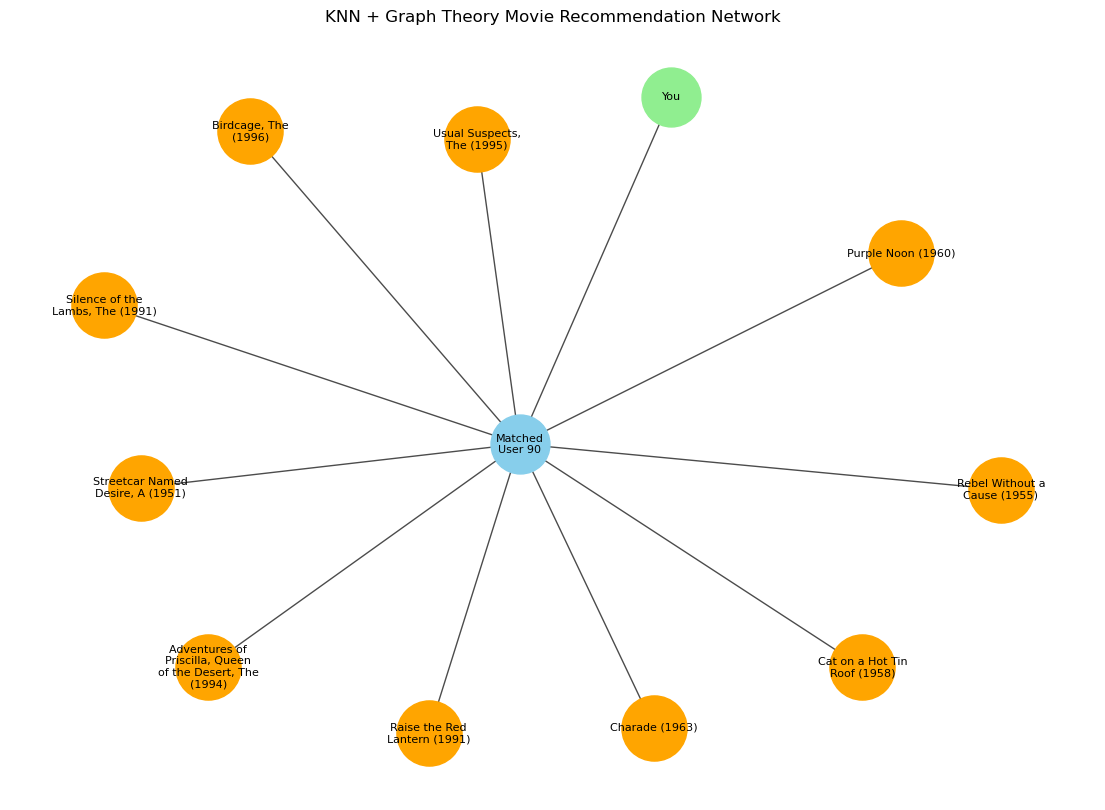

In [32]:
import networkx as nx
import matplotlib.pyplot as plt
import textwrap

# build user and movie graph
G = nx.Graph()

# add all user-movie rating edges
for _, row in ratings.iterrows():
    user_node = f"user_{row['user_id']}"
    movie_node = f"movie_{row['movie_id']}"

    G.add_edge(
        user_node,
        movie_node,
        weight=row["rating"]
    )

# using knn result as a start node
best_user_id = best_match["user_id"]
best_user_node = f"user_{best_user_id}"

print(f"Closest User Found by KNN: {best_user_id}")
print(f"Similarity Score: {best_match['similarity']:.3f}")

# find movies connected to user
recommended_movie_nodes = []

for neighbor in G.neighbors(best_user_node):

    # only keep movie nodes
    if neighbor.startswith("movie_"):

        # exclude movies already rated by the new user
        movie_id = int(neighbor.replace("movie_", ""))

        if movie_id not in mock_user_ratings:
            recommended_movie_nodes.append(neighbor)

# sort by edge weight (higher rated movies first)
recommended_movie_nodes = sorted(
    recommended_movie_nodes,
    key=lambda movie: G[best_user_node][movie]["weight"],
    reverse=True
)

# keep top 10 recommendations
recommended_movie_nodes = recommended_movie_nodes[:10]

# printing recommended movies
movie_map = dict(zip(movies["movie_id"], movies["title"]))

print("\nGraph-Based Recommendations:\n")

for movie_node in recommended_movie_nodes:
    movie_id = int(movie_node.replace("movie_", ""))
    rating = G[best_user_node][movie_node]["weight"]
    print(f"{movie_map[movie_id]}  | predicted interest: {rating}")

# visualize: new quiz user, closest KNN user, movies rated by closest user, highlight recommendations

viz_graph = nx.Graph()

new_user_node = "YOU"

# add edge from YOU -> closest user
viz_graph.add_edge(
    new_user_node,
    best_user_node,
    weight=best_match["similarity"]
)

# add recommended movie nodes
for movie_node in recommended_movie_nodes:
    rating = G[best_user_node][movie_node]["weight"]

    viz_graph.add_edge(
        best_user_node,
        movie_node,
        weight=rating
    )

# creating labels
labels = {}

for node in viz_graph.nodes():

    if node == "YOU":
        labels[node] = "You"

    elif node.startswith("user_"):
        labels[node] = f"Matched\nUser {best_user_id}"

    else:
        movie_id = int(node.replace("movie_", ""))
        title = movie_map.get(movie_id, "Unknown")

        # wraps long titles onto multiple lines
        labels[node] = "\n".join(textwrap.wrap(title, width=18))

# draw the graph
plt.figure(figsize=(14, 10))

pos = nx.spring_layout(
    viz_graph,
    seed=42,
    k=2.5
)

# node groups
user_nodes = [node for node in viz_graph.nodes() if node == "YOU"]
matched_user_nodes = [node for node in viz_graph.nodes() if node.startswith("user_")]
movie_nodes = [node for node in viz_graph.nodes() if node.startswith("movie_")]

# draw "You"
nx.draw_networkx_nodes(
    viz_graph,
    pos,
    nodelist=user_nodes,
    node_color="lightgreen",
    node_size=1800
)

# draw matched KNN user
nx.draw_networkx_nodes(
    viz_graph,
    pos,
    nodelist=matched_user_nodes,
    node_color="skyblue",
    node_size=1800
)

# draw recommended movies
nx.draw_networkx_nodes(
    viz_graph,
    pos,
    nodelist=movie_nodes,
    node_color="orange",
    node_size=2200
)

# draw edges
edge_widths = []

for u, v in viz_graph.edges():
    weight = viz_graph[u][v]["weight"]

nx.draw_networkx_edges(
    viz_graph,
    pos,
    width=edge_widths,
    alpha=0.7
)

# draw labels
nx.draw_networkx_labels(
    viz_graph,
    pos,
    labels,
    font_size=8
)

plt.title("KNN + Graph Theory Movie Recommendation Network")
plt.axis("off")
plt.show()